In [15]:
# Install the package pmdarima
# !pip install pmdarima --quiet

In [16]:
import os
# import datetime
from datetime import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

from matplotlib.pylab import rcParams

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm


# import warnings
# warnings.filterwarnings('ignore')
%matplotlib inline
# use daily averages

In [ ]:
path = "../../datasets/TxSON_data_2026-02-24/"
station_code = "CB01"

df = pd.read_csv(path + station_code + '.dat', skiprows=5, parse_dates=['Date'], index_col='Date')
df.drop(['Flag'], axis=1, inplace=True)
dfs = {station_code: df}

dfs[station_code]

In [ ]:
station = "CB01"
SWC = "SWC_5"

In [ ]:
st1_swc50 = dfs[station][[SWC]]

In [ ]:
st1_swc50

In [ ]:
plt.figure(figsize=(15,7))
plt.title("Soil Moisture in 5cm depth")
plt.xlabel('Date')
plt.ylabel('SWC5')
plt.plot(st1_swc50)
plt.show()

# Augmented Dickey–Fuller Test


In [ ]:
#Augmented Dickey–Fuller test:
print('Results of Dickey Fuller Test:')

dftest = adfuller(st1_swc50[SWC], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
    
print(dfoutput)

In [57]:
print(len(st1_swc50["2015":"2015"]))
print(len(st1_swc50["2016":"2016"]))
print(len(st1_swc50["2017":"2017"]))
print(len(st1_swc50["2018":"2018"]))
print(len(st1_swc50["2019":"2019"]))
# print(len(st1_swc50["2020":"2021"]))

8696
8772
8760
8760
8760


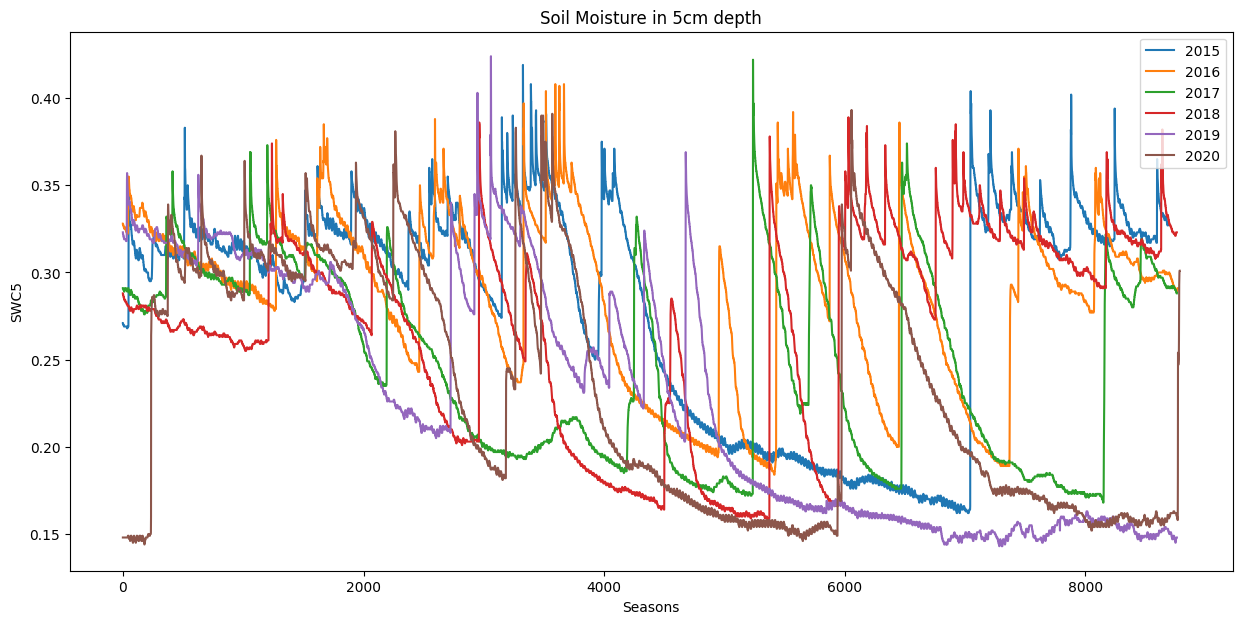

In [58]:
plt.figure(figsize=(15,7))
plt.title("Soil Moisture in 5cm depth")
plt.xlabel('Seasons')
plt.ylabel('SWC5')
plt.plot(st1_swc50["2015":"2015"].reset_index(drop=True), label="2015")
plt.plot(st1_swc50["2016":"2016"].reset_index(drop=True), label="2016")
plt.plot(st1_swc50["2017":"2017"].reset_index(drop=True), label="2017")
plt.plot(st1_swc50["2018":"2018"].reset_index(drop=True), label="2018")
plt.plot(st1_swc50["2019":"2019"].reset_index(drop=True), label="2019")
plt.plot(st1_swc50["2020":"2020"].reset_index(drop=True), label="2020")
plt.legend(loc='upper right')

plt.show()

# ARIMA Model Selection w/ Auto-ARIMA
Data is stationary

In [ ]:
#Standard ARIMA Model
arima_model = pm.auto_arima(st1_swc50.reset_index(drop=True), 
                      start_p=1,
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=24, max_q=24, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=None,# let model determine 'd'
                      seasonal=False, # No Seasonality for standard ARIMA
                      trace=False, #logs
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)

arima_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [102]:
fitted, confint = arima_model.predict(start="2015", end="2020", return_conf_int=True, dynamic=False)

fitted

58365    0.185656
58366    0.185608
58367    0.185570
58368    0.185551
58369    0.185530
58370    0.185510
58371    0.185490
58372    0.185470
58373    0.185451
58374    0.185432
dtype: float64

In [ ]:
index_of_fc = st1_swc50.index

# make series for plotting purpose
fitted_series = pd.Series(fitted.values, index=index_of_fc)

fitted_series

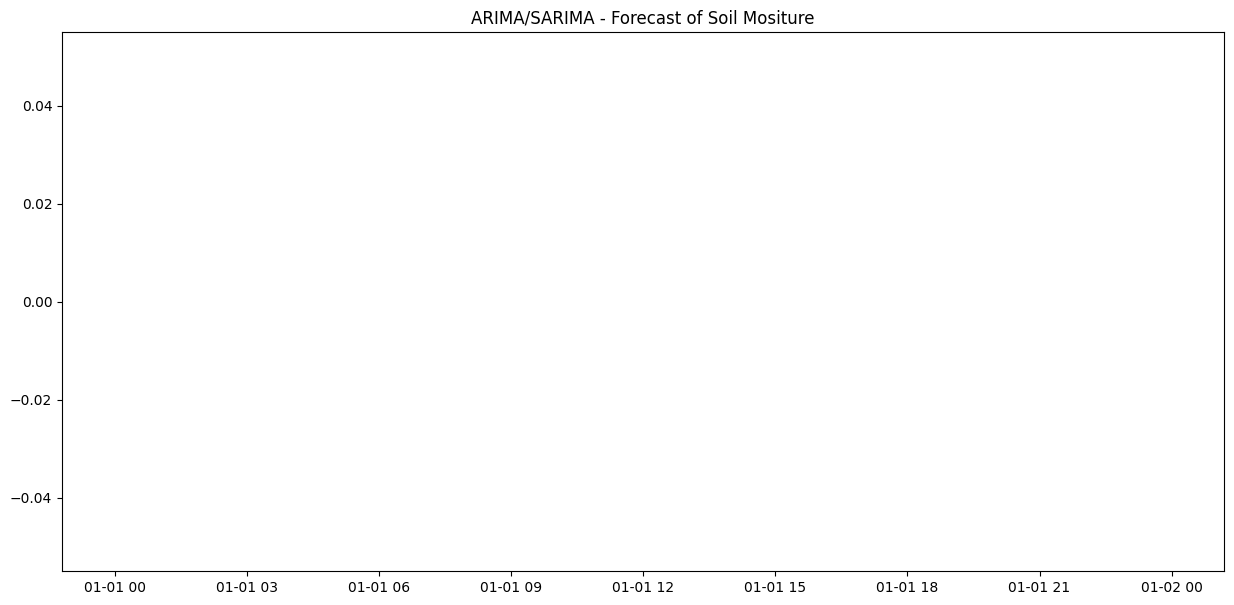

In [105]:
 # Plot
plt.figure(figsize=(15,7))
# plt.plot(st1_swc50_2, color='#1f76b4')
plt.plot(fitted_series, color='darkgreen')

plt.title("ARIMA/SARIMA - Forecast of Soil Mositure")
plt.show()

# Data Split